In [1]:
import requests
from datetime import datetime, timedelta

# Calculate dates
today = datetime.now()
week_ago = today - timedelta(days=7)

# Format dates for API (YYYY-MM-DD)
start_date = week_ago.strftime("%Y-%m-%d")
end_date = today.strftime("%Y-%m-%d")

# Get Tokyo weather for past week
url = f"https://api.open-meteo.com/v1/forecast?latitude=35.6854&longitude=139.7531&start_date={start_date}&end_date={end_date}&daily=temperature_2m_max,temperature_2m_min"

response = requests.get(url)
data = response.json()
print(data)

{'latitude': 35.7, 'longitude': 139.75, 'generationtime_ms': 0.030159950256347656, 'utc_offset_seconds': 0, 'timezone': 'GMT', 'timezone_abbreviation': 'GMT', 'elevation': 25.0, 'daily_units': {'time': 'iso8601', 'temperature_2m_max': '°C', 'temperature_2m_min': '°C'}, 'daily': {'time': ['2026-05-23', '2026-05-24', '2026-05-25', '2026-05-26', '2026-05-27', '2026-05-28', '2026-05-29', '2026-05-30'], 'temperature_2m_max': [17.8, 21.6, 26.7, 26.9, 28.5, 25.4, 30.7, 28.2], 'temperature_2m_min': [12.9, 14.4, 16.5, 17.7, 20.0, 21.0, 16.6, 17.6]}}


In [2]:
import pandas as pd

# Extract the daily data
daily_data = data['daily']

# Create a DataFrame
df = pd.DataFrame({
    'date': daily_data['time'],
    'max_temp': daily_data['temperature_2m_max'],
    'min_temp': daily_data['temperature_2m_min']
})

# Convert date strings to datetime
df['date'] = pd.to_datetime(df['date'])

print(df)

        date  max_temp  min_temp
0 2026-05-23      17.8      12.9
1 2026-05-24      21.6      14.4
2 2026-05-25      26.7      16.5
3 2026-05-26      26.9      17.7
4 2026-05-27      28.5      20.0
5 2026-05-28      25.4      21.0
6 2026-05-29      30.7      16.6
7 2026-05-30      28.2      17.6


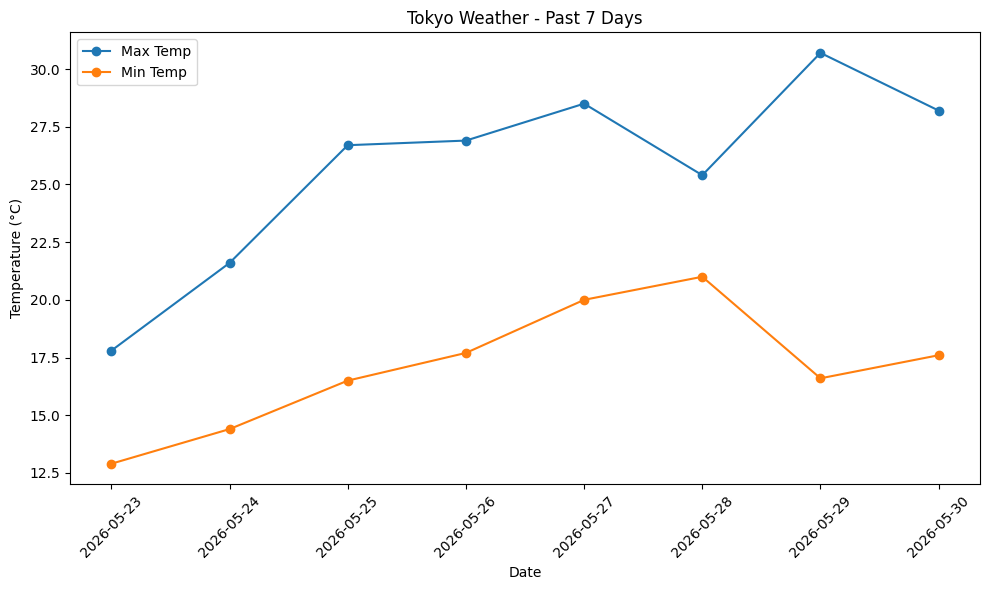

In [3]:
import matplotlib.pyplot as plt

# Create the plot
plt.figure(figsize=(10, 6))
plt.plot(df['date'], df['max_temp'], marker='o', label='Max Temp')
plt.plot(df['date'], df['min_temp'], marker='o', label='Min Temp')

# Add labels and title
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.title('Tokyo Weather - Past 7 Days')
plt.legend()

# Rotate x-axis labels for readability
plt.xticks(rotation=45)
plt.tight_layout()

# Save the plot
plt.savefig('weather_chart.png')
plt.show()

In [5]:
import os

# Create data folder if it doesn't exist
if not os.path.exists('data'):
    os.makedirs('data')

# Save to CSV
df.to_csv('data/tokyo_weather.csv', index=False)
print("Data saved to data/tokyo_weather.csv")


Data saved to data/tokyo_weather.csv
